In [30]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [4]:
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-03-17_OPhys_LabMeetingIV\figures"

In [5]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

In [6]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [ ]:
test_asset = assets[-2]

### Plot mean image response

In [ ]:
mean_data_path = glob.glob(os.path.join(test_asset.derived_dir,'**','glutamate_mean_df.npz'))[0]
glu_qc_path = glob.glob(os.path.join(test_asset.qc_dir,'**','**glutamate**'))[0]

In [ ]:
glu_mean = np.load(mean_data_path,allow_pickle=True)['data'][0]

In [ ]:
with open(glu_qc_path, "r") as f:
    glu_qc = json.load(f)

In [ ]:
im_names = list(glu_mean['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

In [ ]:
dmd = 1
syn = 11

fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for i,im in enumerate(im_names):

    glu_signal = glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]
    time = np.linspace(-0.25,0.5,len(glu_signal))
    ax.plot(time,pd.DataFrame(glu_signal).rolling(1,min_periods=1).mean(),lw=3,color=colors[i])

mean = np.mean([glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]for i,im in enumerate(im_names)],axis=0 )

# ax.fill_between(time[50:100],min(mean[50:100]),mean[50:100],color='lightgray',zorder=0,alpha=0.4,label='AUC')
# ax.fill_between(time[:50],min(mean[:50]),mean[:50],color='lightgray',zorder=0,alpha=0.4)

ax.plot(time,pd.DataFrame(mean).rolling(1,min_periods=1).mean(),color='k',lw=2,label='Mean')

ax.axvline(0.0,color='k',dashes=[5,3],lw=2)
ax.axvspan(0.0,0.25,color='lightgray',alpha=0.4,zorder=0)

ax.set_xlabel('Time (s) from stimulus onset')
ax.set_ylabel('Mean \u0394F')

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

ax.set_title('Mean Image Response')
ax.legend(frameon=False,fontsize=12)
fig.tight_layout()

filen = '2026-03-30_AUC1'
# save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

### Plot photodiode signal

In [ ]:
pd_path = test_asset.photodiode_pkl
bon_path = test_asset.bonsai_event_log_csv

In [ ]:
stim_df = pd.read_csv(bon_path)
pd_df = pd.read_pickle(pd_path)

In [ ]:
pd_df['time'] = pd_df.index-pd_df.index[0]

In [ ]:
stim_df

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

ax.plot(pd_df['time'],pd_df['AnalogInput0'])

ax2 = ax.twinx()
ax2.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax2.tick_params(axis='y',which='major',reset=False,right=True,labelsize=12)

ax2.plot(stim_df['corrected_timestamps'].iloc[5:],stim_df['photodiode_state'].iloc[5:],color='red',dashes=[4,3])
ax2.set_ylabel('Photodiode State (BV)')


ax.set_xlim(-0.25,10)
ax2.set_xlim(-0.25,10)
ax.set_xlabel('HARP time (s)')
ax.set_ylabel('Photodiode State (HARP)')

flash_dur_s = 0.25


# use corrected timestamps if present, otherwise raw Bonsai timestamps
time_col = 'corrected_timestamps' if 'corrected_timestamps' in stim_df.columns else 'Timestamp'

# rows corresponding to image presentations
image_mask = (
    stim_df['Value']
    .astype(str)
    .str.endswith('.tiff', na=False)
)

colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

image_mask = stim_df['Value'].astype(str).str.endswith('.tiff', na=False)
image_events = stim_df.loc[image_mask, [time_col, 'Value']].copy()
image_events = image_events.rename(columns={'Value': 'image_name'})
image_events = image_events.sort_values(time_col)

# unique image identities
unique_images = image_events['image_name'].dropna().unique()
# optional: only show spans that overlap current x-limits
image_to_color = {img: colors[i] for i, img in enumerate(unique_images)}

x0, x1 = ax.get_xlim()
for _, row in image_events.iterrows():
    t = row[time_col]
    img = row['image_name']
    if (t + flash_dur_s >= x0) and (t <= x1):
        ax.axvspan(
            t,
            t + flash_dur_s,
            color=image_to_color[img],
            alpha=0.4,
            zorder=0,
        )


ax.set_title('HARP/BV-encoded photodiode signal')
fig.tight_layout()
filen = '2026-03-30_HARP_photodiode_BV'
save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

ax.plot(stim_df['Timestamp'],stim_df['photodiode_state'])

ax.set_xlim(-0.25,10)
ax.set_xlabel('BonVision time (s)')
ax.set_ylabel('Photodiode State')
ax.set_ylim(-0.1,1.1)
fig.tight_layout()
filen = '2026-03-30_bv_photodiode'
save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

### Synapse QC analysis

In [177]:
qc = []

for asset in assets:
    qc_path = glob.glob(os.path.join(asset.qc_dir,'**','synapse_qc.csv'),recursive=True)[0]
    qc.append(pd.read_csv(qc_path))
qc_df = pd.concat(qc)
qc_df

,session_id,subject_id,dmd,synapse_idx,synapse_id,n_trials_total,n_valid_trials,valid_trial_fraction,n_segments,concat_n_samples,...,residual_snr_linear,residual_snr_db,support_score,finite_score,range_score,residual_snr_score,quality_score,quality_rank_within_dmd,quality_percentile_within_dmd,recommended_for_analysis
0,803496_2025-07-25_13-02-10,803496,1,0,DMD1_syn0000,62,62,1.000000,62,348006,...,0.585350,-4.651689,1.000000,0.999609,1.0,0.373922,0.624275,12.0,0.880435,True
1,803496_2025-07-25_13-02-10,803496,1,1,DMD1_syn0001,62,62,1.000000,62,348006,...,0.520166,-5.677159,1.000000,0.999609,1.0,0.340407,0.604166,29.0,0.695652,True
2,803496_2025-07-25_13-02-10,803496,1,2,DMD1_syn0002,62,62,1.000000,62,348006,...,0.480316,-6.369457,1.000000,0.999609,1.0,0.319041,0.591346,48.0,0.489130,True
3,803496_2025-07-25_13-02-10,803496,1,3,DMD1_syn0003,62,62,1.000000,62,348006,...,0.581655,-4.706695,1.000000,0.999609,1.0,0.372068,0.623163,14.0,0.858696,True
4,803496_2025-07-25_13-02-10,803496,1,4,DMD1_syn0004,62,62,1.000000,62,348006,...,0.612424,-4.258953,1.000000,0.999609,1.0,0.387336,0.632324,6.0,0.945652,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,838410_2026-03-20_10-00-59,838410,2,68,DMD2_syn0068,193,188,0.974093,188,350808,...,0.384600,-8.299824,0.986962,1.000000,1.0,0.264849,0.557606,51.0,0.315068,True
132,838410_2026-03-20_10-00-59,838410,2,69,DMD2_syn0069,193,188,0.974093,188,350808,...,0.444150,-7.049406,0.986962,1.000000,1.0,0.299051,0.578127,11.0,0.863014,True
133,838410_2026-03-20_10-00-59,838410,2,70,DMD2_syn0070,193,188,0.974093,188,350808,...,0.399965,-7.959555,0.986962,1.000000,1.0,0.273831,0.562995,37.0,0.506849,True
134,838410_2026-03-20_10-00-59,838410,2,71,DMD2_syn0071,193,188,0.974093,188,350808,...,0.386747,-8.251468,0.986962,1.000000,1.0,0.266111,0.558363,48.0,0.356164,True


In [178]:
qc_df = pd.concat(qc)
qc_df

,session_id,subject_id,dmd,synapse_idx,synapse_id,n_trials_total,n_valid_trials,valid_trial_fraction,n_segments,concat_n_samples,...,residual_snr_linear,residual_snr_db,support_score,finite_score,range_score,residual_snr_score,quality_score,quality_rank_within_dmd,quality_percentile_within_dmd,recommended_for_analysis
0,803496_2025-07-25_13-02-10,803496,1,0,DMD1_syn0000,62,62,1.000000,62,348006,...,0.585350,-4.651689,1.000000,0.999609,1.0,0.373922,0.624275,12.0,0.880435,True
1,803496_2025-07-25_13-02-10,803496,1,1,DMD1_syn0001,62,62,1.000000,62,348006,...,0.520166,-5.677159,1.000000,0.999609,1.0,0.340407,0.604166,29.0,0.695652,True
2,803496_2025-07-25_13-02-10,803496,1,2,DMD1_syn0002,62,62,1.000000,62,348006,...,0.480316,-6.369457,1.000000,0.999609,1.0,0.319041,0.591346,48.0,0.489130,True
3,803496_2025-07-25_13-02-10,803496,1,3,DMD1_syn0003,62,62,1.000000,62,348006,...,0.581655,-4.706695,1.000000,0.999609,1.0,0.372068,0.623163,14.0,0.858696,True
4,803496_2025-07-25_13-02-10,803496,1,4,DMD1_syn0004,62,62,1.000000,62,348006,...,0.612424,-4.258953,1.000000,0.999609,1.0,0.387336,0.632324,6.0,0.945652,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,838410_2026-03-20_10-00-59,838410,2,68,DMD2_syn0068,193,188,0.974093,188,350808,...,0.384600,-8.299824,0.986962,1.000000,1.0,0.264849,0.557606,51.0,0.315068,True
132,838410_2026-03-20_10-00-59,838410,2,69,DMD2_syn0069,193,188,0.974093,188,350808,...,0.444150,-7.049406,0.986962,1.000000,1.0,0.299051,0.578127,11.0,0.863014,True
133,838410_2026-03-20_10-00-59,838410,2,70,DMD2_syn0070,193,188,0.974093,188,350808,...,0.399965,-7.959555,0.986962,1.000000,1.0,0.273831,0.562995,37.0,0.506849,True
134,838410_2026-03-20_10-00-59,838410,2,71,DMD2_syn0071,193,188,0.974093,188,350808,...,0.386747,-8.251468,0.986962,1.000000,1.0,0.266111,0.558363,48.0,0.356164,True


,group,dmd,synapse_idx,quality_score,session_id
0,best,1,76,0.666217,803496_2025-07-25_13-02-10
1,best,1,83,0.662751,803496_2025-07-25_13-02-10
2,middle,1,75,0.580507,803496_2025-07-25_13-02-10
3,middle,1,40,0.580068,803496_2025-07-25_13-02-10
4,worst,2,45,0.552426,803496_2025-07-25_13-02-10
5,worst,2,53,0.550687,803496_2025-07-25_13-02-10


Using asset: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496


<IPython.core.display.Javascript object>


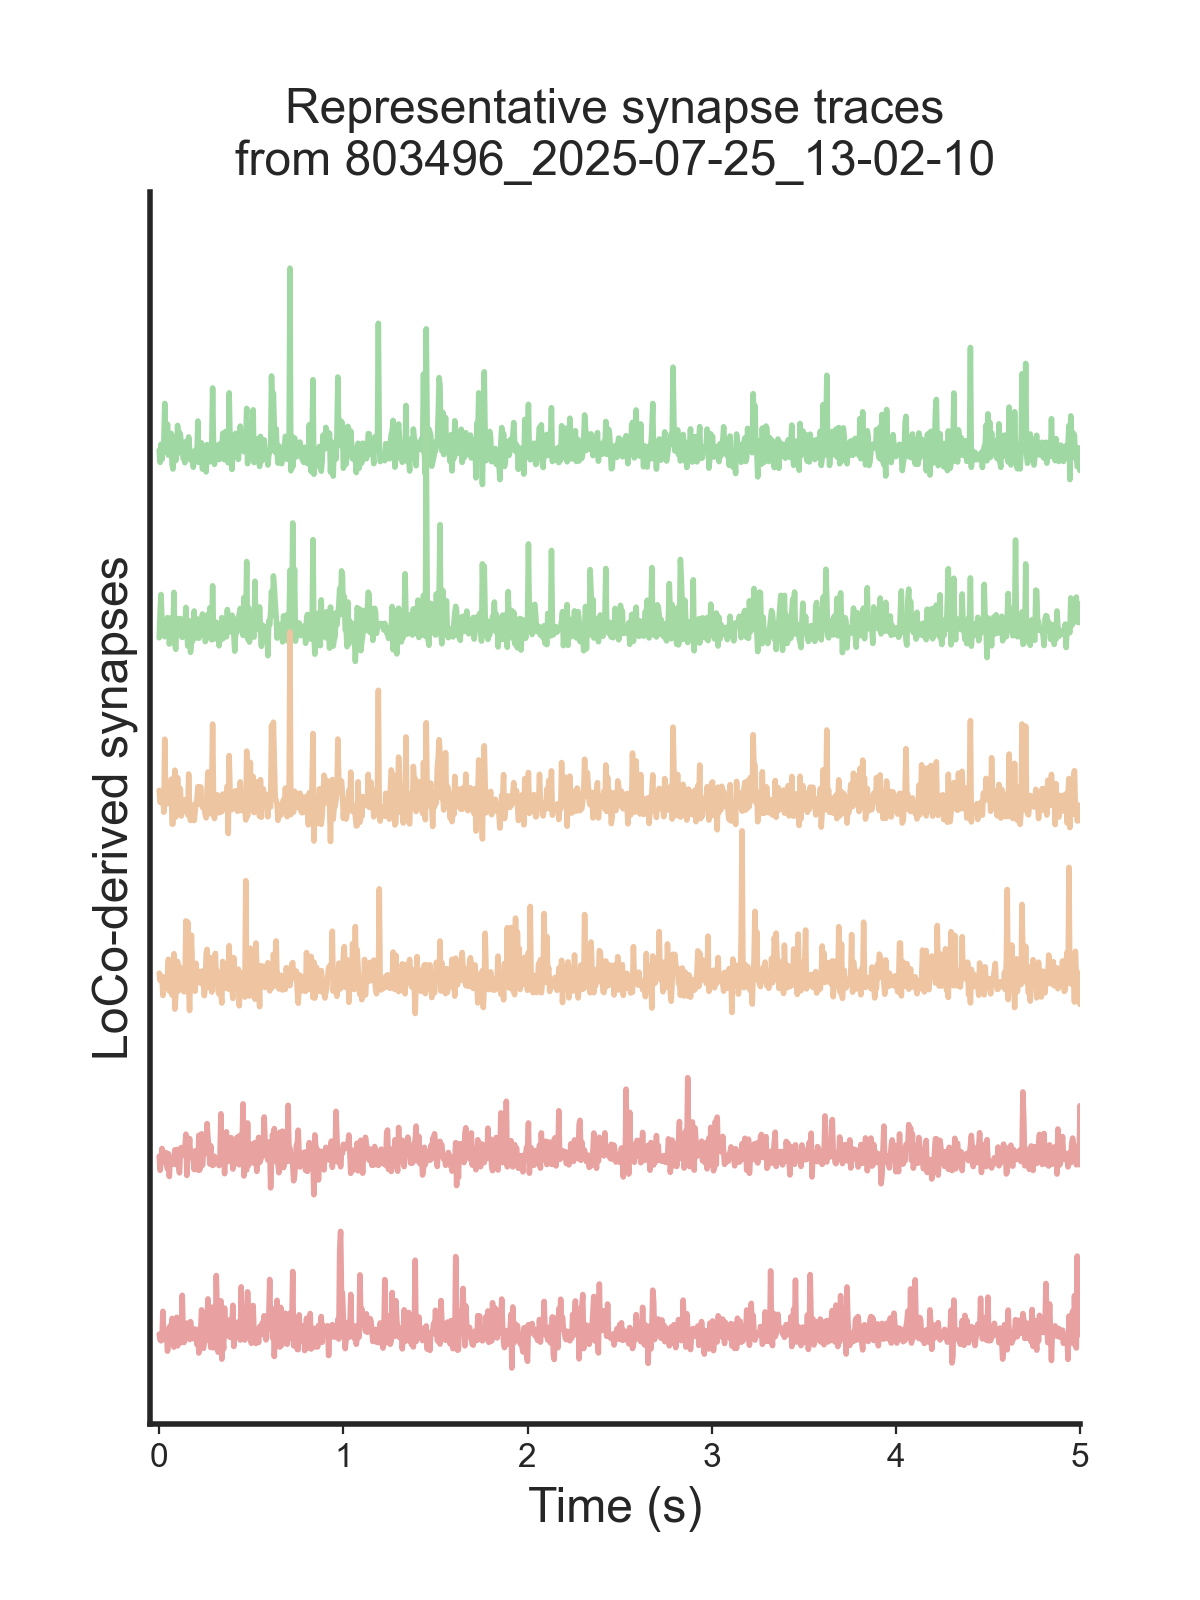

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_60192\1957406794.py:230: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


In [179]:
# ----------------------------
# helper: concatenate one synapse across trials
# ----------------------------
def get_concatenated_synapse_trace(
    gs,
    dmd,
    synapse_idx,
    trial_list=None,
    trace_type="dF",
    channel=0,
):
    if trial_list is None:
        if hasattr(gs, "valid_trials"):
            trial_list = list(gs.valid_trials[dmd - 1])
        else:
            raise ValueError("Please provide trial_list explicitly.")

    traces = []
    trial_lengths = []
    used_trials = []

    for trial in trial_list:
        arr = gs.get_traces(
            dmd=dmd,
            trial=trial,
            signal=trace_type,
            mode='ls'
        )
        arr = np.asarray(arr)

        if arr.ndim == 3:
            tr = arr[synapse_idx, channel, :]
        elif arr.ndim == 2:
            tr = arr[synapse_idx, :]
        else:
            raise ValueError(f"Unexpected trace shape for trial {trial}: {arr.shape}")

        tr = np.asarray(tr, dtype=float).ravel()
        traces.append(tr)
        trial_lengths.append(len(tr))
        used_trials.append(trial)

    concat_trace = np.concatenate(traces, axis=0)
    return concat_trace, trial_lengths, used_trials

from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.pyplot as plt
import numpy as np

pastel_gyr = LinearSegmentedColormap.from_list(
    "pastel_gyr",
    [
        "#9fd8a3",  # pastel green
        "#f3e7a1",  # pastel yellow
        "#e8a0a0",  # pastel red
    ]
)
# ----------------------------
# choose one session: first session in qc_df
# ----------------------------
# adjust these column names if needed after inspecting qc_df.columns
session_cols_priority = [
    ["session_name"],
    ["session_id"],
    ["mouse_id", "session_date"],
    ["mouse", "session"],
]

session_cols = None
for cols in session_cols_priority:
    if all(c in qc_df.columns for c in cols):
        session_cols = cols
        break

if session_cols is None:
    raise ValueError(f"Could not identify session columns from qc_df.columns:\n{qc_df.columns.tolist()}")

first_session_key = qc_df[session_cols].drop_duplicates().iloc[0].to_dict()

mask = np.ones(len(qc_df), dtype=bool)
for c, v in first_session_key.items():
    mask &= (qc_df[c] == v)

sess_qc = qc_df.loc[mask].copy()

# require DMD + synapse index + quality score
required_cols = ["dmd", "synapse_idx", "quality_score"]
missing = [c for c in required_cols if c not in sess_qc.columns]
if missing:
    raise ValueError(f"Missing required QC columns: {missing}")

sess_qc = sess_qc.dropna(subset=["quality_score"]).sort_values("quality_score").reset_index(drop=True)

if len(sess_qc) < 6:
    raise ValueError(f"Need at least 6 synapses in the selected session, found {len(sess_qc)}")

# ----------------------------
# pick 2 worst, 2 middle, 2 best
# ----------------------------
worst_df = sess_qc.iloc[:2].copy()

mid_start = max(0, len(sess_qc) // 2 - 1)
middle_df = sess_qc.iloc[mid_start:mid_start + 2].copy()

best_df = sess_qc.iloc[-2:].copy()

selected = pd.concat([
    worst_df.assign(group="worst"),
    middle_df.assign(group="middle"),
    best_df.assign(group="best"),
], ignore_index=True)

# optional: order top-to-bottom as best, middle, worst in the plot
selected["group_order"] = selected["group"].map({"best": 0, "middle": 1, "worst": 2})
selected = selected.sort_values(["group_order", "quality_score"], ascending=[True, False]).reset_index(drop=True)

display(selected[["group", "dmd", "synapse_idx", "quality_score"] + [c for c in session_cols if c in selected.columns]])

# ----------------------------
# match to asset
# ----------------------------
# you may need to customize this if your asset object uses different attributes
def asset_matches_session(asset, session_key):
    for c, v in session_key.items():
        if hasattr(asset, c):
            if getattr(asset, c) != v:
                return False
        elif c == "session_name" and hasattr(asset, "session_dir"):
            if os.path.basename(str(asset.session_dir)) != str(v):
                return False
        else:
            # ignore unmatched fields for now
            pass
    return True

candidate_assets = [a for a in assets if asset_matches_session(a, first_session_key)]
if len(candidate_assets) == 0:
    raise ValueError(f"Could not match selected session to an asset using key: {first_session_key}")
asset = candidate_assets[0]

print("Using asset:", getattr(asset, "session_dir", asset))

# ----------------------------
# load glutamate summary
# ----------------------------
# adapt this import / constructor to your current repo
# examples:
# from vip_slap2_analysis.glutamate.summary import GlutamateSummary
# gs = GlutamateSummary(asset.summary_mat_path)

from vip_slap2_analysis.glutamate.summary import GlutamateSummary

# try a few likely asset attrs for the summary path
summary_path_candidates = [
    getattr(asset, "summary_mat_path", None),
    getattr(asset, "glutamate_summary_path", None),
    getattr(asset, "summary_path", None),
    getattr(asset,'summary_mat',None)
]
summary_path_candidates = [p for p in summary_path_candidates if p is not None]

if len(summary_path_candidates) == 0:
    raise ValueError("Could not find summary path on asset. Add your summary path explicitly.")

gs = GlutamateSummary(summary_path_candidates[0])

# ----------------------------
# plot selected synapses
# ----------------------------
fs = 200.0
trace_type = "dF"
channel = 0
offset_step = 150  # vertical separation
plot_seconds = None  # set to e.g. 300 to show only first 5 min

scores = selected["quality_score"].to_numpy()

norm = Normalize(vmin=np.nanmin(scores), vmax=np.nanmax(scores))

# invert so high score -> green, low score -> red
colors = [pastel_gyr(1 - norm(s)) for s in scores]

fig, ax = plt.subplots(figsize=(6, 8))
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
n = len(selected)
for i, (_, row) in enumerate(selected.iterrows()):
    dmd = int(row["dmd"])
    synapse_idx = int(row["synapse_idx"])
    q = float(row["quality_score"])
    group = row["group"]

    trace, trial_lengths, used_trials = get_concatenated_synapse_trace(
        gs,
        dmd=dmd,
        synapse_idx=synapse_idx,
        trace_type=trace_type,
        channel=channel,
    )

    t = np.arange(trace.size) / fs
    trace_centered = trace - np.nanmedian(trace)
    y_offset = (n - 1 - i) * offset_step

    ax.plot(
        t,
        trace_centered + y_offset,
        lw=2,
        color=colors[i],
    )

    ax.text(
        t[-1] + 2,
        y_offset,
        f"DMD{dmd} syn {synapse_idx} | score={q:.2f}",
        va="center",
        fontsize=10,
        color=colors[i],
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("LoCo-derived synapses")
ax.set_title(f"Representative synapse traces\nfrom {asset.session_id}")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-0.05,5)
ax.set_yticks([])
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
fig.tight_layout()
filen = '2026-03-30_synapse_traces_qc'
save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

In [180]:
qc_df.keys()

Index(['session_id', 'subject_id', 'dmd', 'synapse_idx', 'synapse_id',
       'n_trials_total', 'n_valid_trials', 'valid_trial_fraction',
       'n_segments', 'concat_n_samples', 'finite_fraction', 'trace_median',
       'trace_mad', 'trace_sigma_robust', 'trace_abs_p95', 'trace_abs_p99',
       'trace_iqr', 'trace_range_robust', 'fs_hz', 'smooth_sigma_robust',
       'residual_sigma_robust', 'residual_snr_linear', 'residual_snr_db',
       'support_score', 'finite_score', 'range_score', 'residual_snr_score',
       'quality_score', 'quality_rank_within_dmd',
       'quality_percentile_within_dmd', 'recommended_for_analysis'],
      dtype='object')

<IPython.core.display.Javascript object>


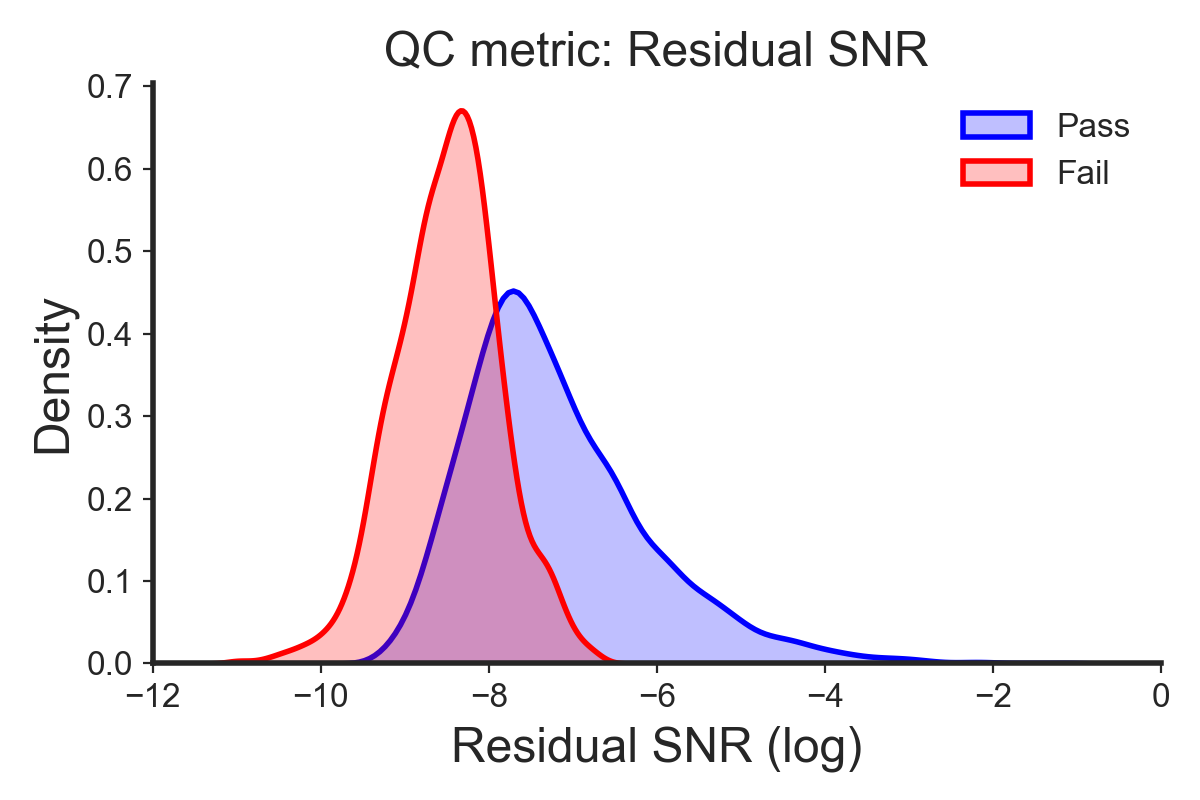

In [181]:
fig,ax=plt.subplots(figsize=(6,4))
sns.despine()
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

p = qc_df[qc_df['recommended_for_analysis']==True]['residual_snr_db']
f = qc_df[qc_df['recommended_for_analysis']==False]['residual_snr_db']

sns.kdeplot(p,label='Pass',lw=2,fill=True,color='b')
sns.kdeplot(f,label='Fail',lw=2,fill=True,color='r')

ax.set_xlabel('Residual SNR (log)')
ax.legend(frameon=False,fontsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
ax.set_xlim(-12,0)
ax.set_title('QC metric: Residual SNR')
fig.tight_layout()
filen = '2026-03-30_residual_SNR'
save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

<IPython.core.display.Javascript object>


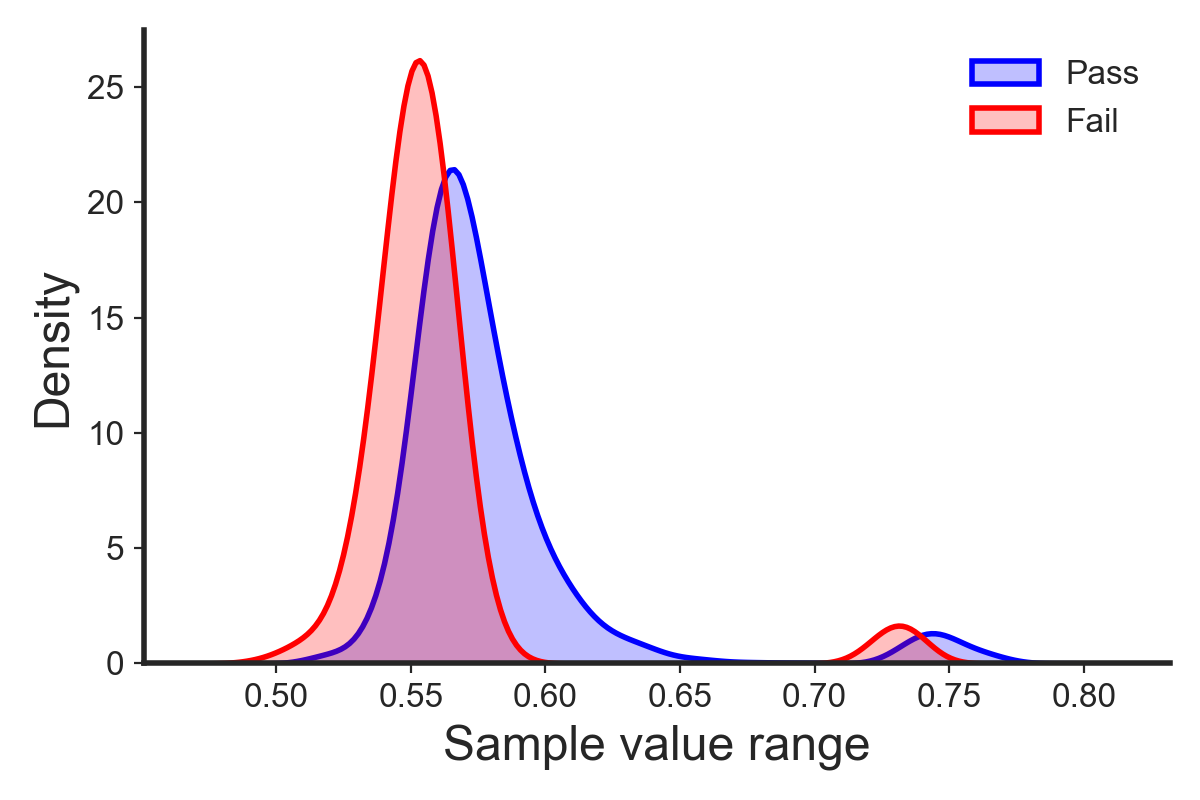

In [182]:
fig,ax=plt.subplots(figsize=(6,4))
sns.despine()
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

p = qc_df[qc_df['recommended_for_analysis']==True]['quality_score']
f = qc_df[qc_df['recommended_for_analysis']==False]['quality_score']

sns.kdeplot(p,label='Pass',lw=2,fill=True,color='b')
sns.kdeplot(f,label='Fail',lw=2,fill=True,color='r')

ax.set_xlabel('Sample value range')
ax.legend(frameon=False,fontsize=12)

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
# ax.set_xlim(-2000,4000)
fig.tight_layout()